In [547]:
from types import NoneType

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

class Layer:
    def xavier_initialization(self):
        mu = 0 # mean is 0 for Xavier_init
        sigma = np.sqrt(6 / self.n_input + self.n_output)

        return self.rng.normal(mu, sigma, size=self.shape)

    def initialize(self, init_method: str="Xavier", **kwargs) -> np.ndarray:
        if init_method == "Xavier":
            return self.xavier_initialization()
        else:
            return np.zeros(shape=self.shape)

    def bias_initialize(self, init_method: str=""):
        if init_method == "Zero":
            return np.zeros(shape=self.n_output)
        else:
            return np.zeros(shape=self.n_output)

    def __init__(self, n_input: int, n_output: int, **kwargs):
        # initialize random state 
        self.random_state = kwargs["random_state"] if "random_state" in kwargs else None
        self.rng = np.random.default_rng(seed=self.random_state)

        # initialize matrix shape
        self.n_input = n_input
        self.n_output = n_output
        self.shape = (n_output, n_input)

        # initialize matrix values
        weight_init_method = kwargs["weight_init"] if "weight_init" in kwargs else "Xavier"
        self.weights = self.initialize(weight_init_method, **kwargs)
        self.biases = self.bias_initialize()

        # outputs required
        self.raw_outputs = np.zeros(n_output)
        self.outputs = np.zeros(n_output)
        self.deltas = np.zeros(n_output)

        # activation methods
        self.activation_method = kwargs["activation_method"] if "activation_method" in kwargs else "sigmoid"
    
    def __str__(self) -> str:
        self_str = ""
        for neuron_index in range(self.n_output):
            self_str += "{("
            for weight in self.weights[neuron_index]:
                self_str += f"{weight:.3g}, "
            self_str += f") + {self.biases[neuron_index]:.3g}}}, "
        return self_str
    
    def __repr__(self) -> str:
        return str(self) + "\n"

    def sigmoid(self, X: np.ndarray | float):
        return 1 / (1 + np.exp(-X))

    def activate(self, X: np.ndarray):
        if self.activation_method == "sigmoid":
            return self.sigmoid(X)
        else:
            return X
    
    def activation_derivative(self, X: float):
        if self.activation_method == "sigmoid":
            return self.sigmoid(X) * (1 - self.sigmoid(X))
        else:
            return 1 # for default no activation function, derivative is 1

    def process(self, input: np.ndarray):
        if (input.shape[0] != (self.n_input)):
            raise ValueError(f"Input shape ({input.shape}, n) must equal layer input shape ({self.shape})")
        
        self.raw_outputs = self.weights @ input + self.biases
        self.outputs = self.activate(self.raw_outputs)

        return self.outputs

In [548]:
layer = Layer(2, 1, random_state = 42)

print(layer.process(np.array([0.1, 0.2])))

[0.41215829]


In [ ]:
class NeuralNet:
    def __init__(self, layer_sizes: tuple, learning_rate: float = 0.01, **kwargs):
        if len(layer_sizes) < 2:
            raise ValueError(f"Shape must have at least two layers")

        # learning params
        self.learning_rate = learning_rate
        
        self.shape = layer_sizes
        self.random_state = kwargs["random_state"] if "random_state" in kwargs else None

        self.layers: list[Layer] = []
        prev_layer_size = 0
        for index, layer_size in enumerate(layer_sizes):
            if (index == 0):
                prev_layer_size = layer_size
                continue # skip the input layer (we already take inputs as they are)
            self.layers.append(Layer(prev_layer_size, layer_size, random_state=self.random_state))
            prev_layer_size = layer_size
    
    def __str__(self):
        self_str = ""
        for layer in reversed(self.layers):
            self_str += str(layer) + "\n"
        return self_str
    
    def process(self, inputs: np.ndarray):
        current_inputs = inputs
        for layer in self.layers:
            current_inputs = layer.process(current_inputs)
        
        return current_inputs
    
    def eval(self, inputs: np.ndarray):
        outputs = []
        for i in range(len(inputs)):
            print(inputs[i])
            outputs.append(self.process(inputs[i]))
        return np.array(outputs)

    def BCE(self, y_pred_all: np.ndarray, y_exp_all: np.ndarray):
        n: int = len(y_pred_all)
        epsilon = 0.00001
        loss_BCE = 0

        for y_pred, y_exp in zip(y_pred_all, y_exp_all):
            loss_BCE += y_exp * np.log(y_pred + epsilon) + (1 - y_exp) * np.log(1 - y_pred + epsilon)

        loss_BCE *= - 1 / n

        return loss_BCE

    def BCE_prime(self, y_pred: float, y_exp: float):
        epsilon = 0.000001
        return (y_pred - y_exp) / (y_pred * (1 - y_pred) + epsilon)

    def train(self, X: np.ndarray, y_exp: np.ndarray, epochs = 10, display=True, verbose=False):
        epoch_losses = np.zeros(epochs)
        momentum = 1
        momentum_degree = 1 # the running count of momentum
        prev_loss = 9999
        for epoch in range(epochs):
            losses = []
            direction = 1
            Y_pred = []
            for X_i, y_exp_i in zip(X, y_exp):
                y_pred = self.process(X_i)
                Y_pred.append(y_pred)

                # backpropogation
                for i in reversed(range(len(self.layers))): # TODO: fix this weird reversed loop
                    # for each layer, starting from the last, go through each node and calculate the deltas
                    
                    for j in range(len(self.layers[i].weights)):
                        raw_output_j = self.layers[i].raw_outputs[j]
                        if i == len(self.layers) - 1:
                            delta_j = self.BCE_prime(y_pred[j], y_exp_i[j]) * self.layers[i].activation_derivative(raw_output_j)
                            self.layers[i].deltas[j] = delta_j
                        else:
                            sum_delta_l = np.sum([delta_l for delta_l in self.layers[i + 1].deltas])
                            delta_j = sum_delta_l * self.layers[i].activation_derivative(raw_output_j)
                            self.layers[i].deltas[j] = delta_j
                        
                        for k in range(len(self.layers[i].weights[j])):
                            if i != 0:
                                output_k = self.layers[i - 1].outputs[k]
                            else:
                                output_k = X_i[k]
                            big_delta_weight = momentum * -self.learning_rate * output_k * delta_j
                            self.layers[i].weights[j, k] += big_delta_weight
                            self.layers[i].biases[j] -= delta_j
                        # big Delta = - learning_rate * node_output_i * delta_j
                        # if outer neuron: delta_j = BCE_prime * logistic_prime
                        # if inner neuron: delta_j = (sum of delta_l for every l in the layer size L) * (logistic_prime)
                        # what we need: a matrix of outputs to fill and a matrix of deltas to fill
                loss = self.BCE(y_pred, y_exp_i)
                #if (y_exp_i == 0 and epoch > 150 and epoch % 10 == 0 and y_pred > 0.5): print(y_pred, y_exp_i, loss)
                losses.append(loss)
            if (epoch == epochs - 1): print(self)
            epoch_loss = np.mean(losses)
            epoch_losses[epoch] = epoch_loss
            greatest_momentum_since = 0
            if prev_loss < epoch_loss:
                greatest_momentum_since = momentum
                momentum_degree *= 0.98
                momentum = 0.5 if momentum > 1 else momentum_degree
            else:
                momentum *= 1.02
            prev_loss = epoch_loss
            if display and epoch % 10 == 0:
                if verbose: print(f"EPOCH: {epoch}    LOSS: {epoch_loss}    MOMENTUM: {momentum}    GM: {greatest_momentum_since}    X_i = {X_i} y_pred = {y_pred}")
                else: print(f"EPOCH: {epoch}    LOSS: {epoch_loss}    MOMENTUM: {momentum}")
        return epoch_losses, np.array(Y_pred)
                
            
        
neural_net = NeuralNet((2, 2, 1), learning_rate=1, random_state=42)
result = neural_net.process(np.array([0.1, 0.2]))

print(neural_net.BCE(result, np.array([0.5])))

neural_net.train(np.array([np.array([0.1, 0.2])]), np.array([np.array([0.5])]), 100)

print(neural_net.BCE(result, np.array([0.5])))

0.8354159385716373
EPOCH: 0    LOSS: 0.8354159385716373    MOMENTUM: 1.02    GM: 0    X_i = [0.1 0.2] y_pred = [0.25116377]
EPOCH: 10    LOSS: 0.693127180834996    MOMENTUM: 1.2433743083946525    GM: 0    X_i = [0.1 0.2] y_pred = [0.49999387]
EPOCH: 20    LOSS: 0.6931271807599428    MOMENTUM: 0.9603999999999999    GM: 0.5202    X_i = [0.1 0.2] y_pred = [0.5]
EPOCH: 30    LOSS: 0.6931271807599427    MOMENTUM: 1.1707222409629645    GM: 0    X_i = [0.1 0.2] y_pred = [0.5]
EPOCH: 40    LOSS: 0.6931271807599427    MOMENTUM: 1.4271038790976112    GM: 0    X_i = [0.1 0.2] y_pred = [0.5]
EPOCH: 50    LOSS: 0.6931271807599427    MOMENTUM: 1.7396316653728605    GM: 0    X_i = [0.1 0.2] y_pred = [0.5]
EPOCH: 60    LOSS: 0.6931271807599427    MOMENTUM: 2.1206012929357043    GM: 0    X_i = [0.1 0.2] y_pred = [0.5]
EPOCH: 70    LOSS: 0.6931271807599427    MOMENTUM: 2.585001143122292    GM: 0    X_i = [0.1 0.2] y_pred = [0.5]
EPOCH: 80    LOSS: 0.6931271807599427    MOMENTUM: 3.1511019691461435    GM

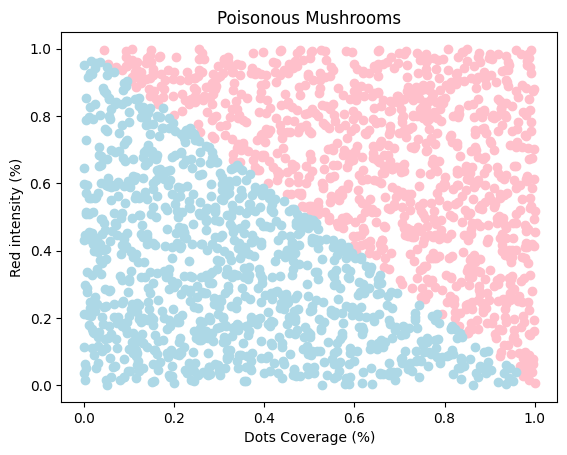

EPOCH: 0    LOSS: 1.162496571232448    MOMENTUM: 1.02    GM: 0    X_i = [0.33966246 0.18035372] y_pred = [0.10582391]
EPOCH: 10    LOSS: 1.1550499025506074    MOMENTUM: 1.2433743083946525    GM: 0    X_i = [0.33966246 0.18035372] y_pred = [0.1056255]
EPOCH: 20    LOSS: 1.147491331379011    MOMENTUM: 1.515666343897922    GM: 0    X_i = [0.33966246 0.18035372] y_pred = [0.10528739]
EPOCH: 30    LOSS: 1.1379308882404133    MOMENTUM: 1.847588815785422    GM: 0    X_i = [0.33966246 0.18035372] y_pred = [0.10486787]
EPOCH: 40    LOSS: 1.1257586681624394    MOMENTUM: 2.252200456887151    GM: 0    X_i = [0.33966246 0.18035372] y_pred = [0.10434788]
EPOCH: 50    LOSS: 1.110195696142565    MOMENTUM: 2.7454197896550796    GM: 0    X_i = [0.33966246 0.18035372] y_pred = [0.10369957]
EPOCH: 60    LOSS: 1.0902411295934864    MOMENTUM: 3.3466514041327216    GM: 0    X_i = [0.33966246 0.18035372] y_pred = [0.10288401]
EPOCH: 70    LOSS: 1.0646324398493139    MOMENTUM: 4.079549387305407    GM: 0    X_i

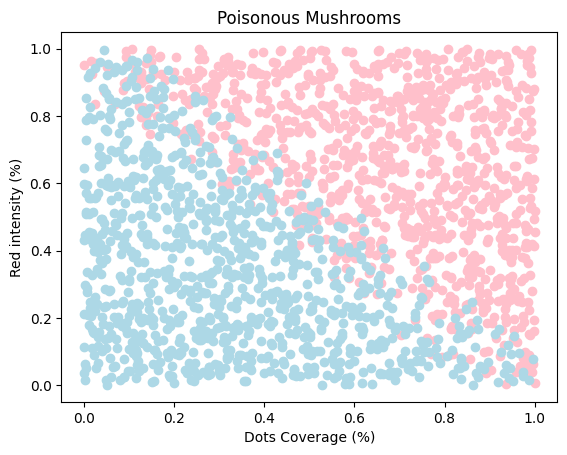

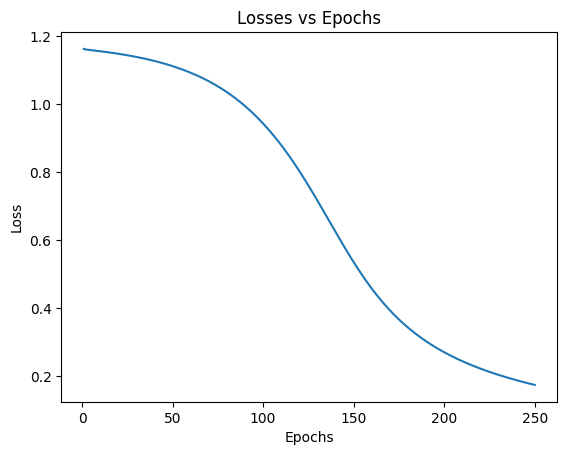

[[0.96945335]
 [0.99822552]
 [0.78938788]
 ...
 [0.00125665]
 [0.00401328]
 [0.00341716]]
[0.17484528]


In [552]:
def generate_mushrooms(ruleset, size_shrooms = 2000):
    rng = np.random.default_rng(seed=42)
    mushrooms = []
    poisonous = []
    for _ in range(size_shrooms):
        redness = rng.random()
        dots = rng.random()
        is_poisonous = ruleset(redness, dots)
        mushrooms.append([redness, dots])
        poisonous.append([1 if is_poisonous else 0])
    return np.array(mushrooms), np.array(poisonous)

X, y = generate_mushrooms(lambda i, j: i + j > 1)

df = pd.DataFrame({
    "redness(%)": X[:, 0],
    "dots(%)": X[:, 1],
    "poisonous": y[:, 0]
})

def generate_mushroom_plot(df: pd.DataFrame):
    poisonous = df[df["poisonous"] >= 0.5]
    not_poisonous = df[df["poisonous"] < 0.5]
    poisonous_x = poisonous["redness(%)"]
    poisonous_y = poisonous["dots(%)"]
    not_poisonous_x = not_poisonous["redness(%)"]
    not_poisonous_y = not_poisonous["dots(%)"]

    plt.scatter(poisonous_x, poisonous_y, c="pink")
    plt.scatter(not_poisonous_x, not_poisonous_y, c="lightblue")

    # Add labels and a title
    plt.xlabel('Dots Coverage (%)')
    plt.ylabel('Red intensity (%)')
    plt.title('Poisonous Mushrooms')
    plt.show()

def plot_losses(epochs: int, losses: np.ndarray):
    plt.plot(np.arange(1, epochs + 1), losses)
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Losses vs Epochs')
    plt.show()

generate_mushroom_plot(df)

shroom_neural_net = NeuralNet((2, 3, 1), learning_rate = 0.00005, random_state=42)

losses = []
num_epochs = 250
losses, y_pred = shroom_neural_net.train(X, y, num_epochs, display=True)

df_pred = pd.DataFrame({
    "redness(%)": X[:, 0],
    "dots(%)": X[:, 1],
    "poisonous": y_pred[:, 0]
})

print(y_pred.shape)

generate_mushroom_plot(df_pred)

plot_losses(num_epochs, losses)
print(y_pred)
print(shroom_neural_net.BCE(y_pred, y))

[0.77395605 0.43887844]
[0.85859792 0.69736803]
[0.09417735 0.97562235]
[0.7611397  0.78606431]
[0.12811363 0.45038594]
[0.37079802 0.92676499]
[0.64386512 0.82276161]
[0.4434142  0.22723872]
[0.55458479 0.06381726]
[0.82763117 0.6316644 ]
[0.75808774 0.35452597]
[0.97069802 0.89312112]
[0.7783835  0.19463871]
[0.466721   0.04380377]
[0.15428949 0.68304895]
[0.74476216 0.96750973]
[0.32582536 0.37045971]
[0.46955581 0.18947136]
[0.12992151 0.47570493]
[0.22690935 0.66981399]
[0.43715192 0.8326782 ]
[0.7002651  0.31236664]
[0.8322598  0.80476436]
[0.38747838 0.2883281 ]
[0.6824955  0.13975248]
[0.1999082  0.00736227]
[0.78692438 0.66485086]
[0.70516538 0.78072903]
[0.45891578 0.5687412 ]
[0.139797   0.11453007]
[0.66840296 0.47109621]
[0.56523611 0.76499886]
[0.63471832 0.5535794 ]
[0.55920716 0.3039501 ]
[0.03081783 0.43671739]
[0.21458467 0.40852864]
[0.85340307 0.23393949]
[0.05830274 0.28138389]
[0.29359376 0.66191651]
[0.55703215 0.78389821]
[0.66431354 0.40638686]
[0.81402038 0.16

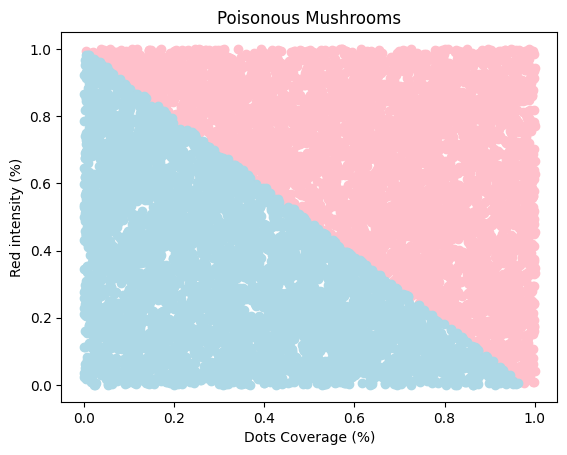

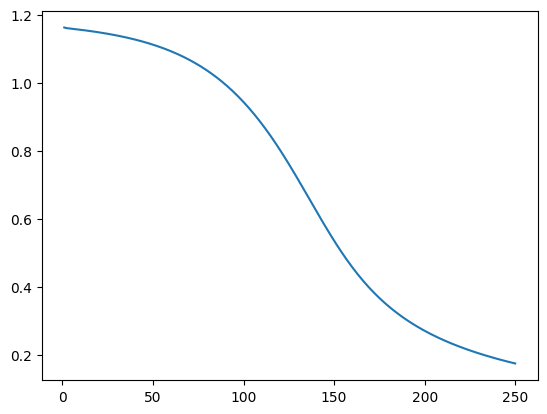

In [555]:
X, y = generate_mushrooms(lambda i, j: i + j > 1, 10000)

y_pred = shroom_neural_net.eval(X)

df_pred = pd.DataFrame({
    "redness(%)": X[:, 0],
    "dots(%)": X[:, 1],
    "poisonous": y_pred[:, 0]
})

print(y_pred.shape)

generate_mushroom_plot(df_pred)

plt.plot(np.arange(1, num_epochs + 1), losses)
plt.show()